# Asistente Turístico de Tenerife 2026
## Máster en Inteligencia Artificial, Cloud Computing y DevOps
## Módulo: Large Language Models
## Autor: Alexander De Sousa

Este notebook documenta el desarrollo completo de un asistente turístico basado en modelos de lenguaje de gran tamaño (LLM) con:

- Recuperación aumentada (RAG) sobre una guía turística real.
- Diálogo multiturno con memoria conversacional.
- Llamadas a herramientas externas (function calling).
- Evaluación del sistema y análisis crítico.
- Integración con herramientas externas/adicionales: clima, restaurantes, webcams, bicicletas y transporte.

---


## 1. Introducción y objetivo

El objetivo de este cuaderno es documentar, de forma reproducible, el funcionamiento de un asistente turístico de Tenerife que:

- Utiliza un modelo comercial (OpenAI) para la generación de respuestas.
- Emplea un pipeline de Recuperación Aumentada (RAG) sobre un PDF con información turística de Tenerife.
- Mantiene memoria conversacional para gestionar diálogo multiturno.
- Invoca herramientas externas (function calling) para obtener información adicional (por ejemplo, clima, transporte, restaurantes).
- Incluye una evaluación básica del RAG y un análisis crítico de las limitaciones y posibles mejoras.



## 2. Configuración e imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.rag import build_rag_pipeline, retrieve
from src.assistant import TenerifeAssistant
from src.tools import (
    get_weather,
    get_bus_stops,
    get_restaurant_offers,
    get_webcams,
    get_bike_rentals,
    # get_transport_info  # opcional
)

PDF_PATH = Path("data") / "TENERIFE.pdf"
PDF_PATH

PosixPath('data/TENERIFE.pdf')

## 3. Guía turística y objetivo del RAG

Trabajamos con una guía turística de Tenerife en formato PDF (`data/TENERIFE.pdf`).

El objetivo del componente RAG es:

- Extraer el contenido de la guía.
- Dividirlo en fragmentos (chunks) manejables.
- Generar embeddings para cada fragmento.
- Indexar los embeddings en FAISS para permitir recuperación semántica.
- Proporcionar al modelo de lenguaje los fragmentos más relevantes como contexto, junto con metadatos (por ejemplo, número de página).

## 4. Construcción del pipeline RAG

En esta sección se construye el pipeline RAG a partir del PDF:

- Carga del documento.
- Chunking del texto.
- Cálculo de embeddings.
- Construcción del índice FAISS.


In [2]:
rag = build_rag_pipeline(str(PDF_PATH))

print("Número de páginas:", len(rag["pages"]))
print("Número de chunks:", len(rag["chunks"]))
print("Forma de los embeddings:", rag["embeddings"].shape)

2026-06-12 01:02:32,533 - src.rag - INFO - Iniciando pipeline RAG para: data/TENERIFE.pdf
2026-06-12 01:02:32,535 - src.rag - INFO - Cargando PDF desde: data/TENERIFE.pdf
2026-06-12 01:02:33,168 - src.rag - INFO - PDF cargado: 25 páginas
2026-06-12 01:02:33,170 - src.rag - INFO - Segmentando texto: chunk_size=800, overlap=150
2026-06-12 01:02:33,173 - src.rag - INFO - Texto segmentado en 35 chunks con metadatos
2026-06-12 01:02:33,240 - src.rag - INFO - Generando embeddings para 35 chunks...
2026-06-12 01:02:35,441 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:02:35,460 - src.rag - INFO - Embeddings generados: forma (35, 1536)
2026-06-12 01:02:35,462 - src.rag - INFO - Construyendo índice FAISS...
2026-06-12 01:02:35,466 - src.rag - INFO - Índice FAISS creado con 35 vectores
2026-06-12 01:02:35,466 - src.rag - INFO - Pipeline RAG completado exitosamente


Número de páginas: 25
Número de chunks: 35
Forma de los embeddings: (35, 1536)


## 5. Ejemplo de chunking y metadatos

A continuación se muestran algunos ejemplos de chunks generados a partir del PDF, junto con sus metadatos (por ejemplo, número de página).

In [3]:
for i in range(3):
    meta = rag["metadata"][i]
    print(f"Chunk {i} (página {meta.get('page', 'N/A')}):")
    print(rag["chunks"][i][:400], "...")
    print("-" * 80)

Chunk 0 (página 1):
TENERIFE – LUGARES DE INTERÉS 
SITIOS QUE VER 
 
ZONA NORTE 
 
• Santa Cruz de Tenerife: 
Santa Cruz de Tenerife es la capital de la isla. Quizás la ruta a seguir si vais a Santa 
Cruz sería: 
- Aparcar en el aparcamiento del Parque Marítimo (ubicación). 
- Caminar por la Avenida Marítima hasta Plaza de España (ubicación). 
- Por el camino de la Avenida Marítima, ver el auditorio de Tenerife (ubic ...
--------------------------------------------------------------------------------
Chunk 1 (página 1):
- Volver de nuevo a por el coche. 
- Ir hacia la playa de Las Teresitas (ubicación). 
Los puntos de interés sugeridos son estos: 
o Parque Marítimo César Manrique [vídeo - ubicación] 
Conjunto de piscinas naturales. ...
--------------------------------------------------------------------------------
Chunk 2 (página 2):
o Auditorio de Tenerife [vídeo - ubicación] 
 
 
o Plaza de España [vídeo - ubicación] ...
--------------------------------------------------------------

## 6. Ejemplo de recuperación semántica (RAG)

Probamos una consulta típica de usuario y observamos qué fragmentos recupera el índice FAISS. Esto permite inspeccionar si el RAG está encontrando información relevante en la guía.

In [4]:
query = "Qué puedo ver en el Teide"

results = retrieve(
    query=query,
    chunks=rag["chunks"],
    index=rag["index"],
    metadata=rag["metadata"],
    k=3,
)

for i, r in enumerate(results, start=1):
    print(f"[{i}] índice {r['index']} | página {r.get('page', 'N/A')}")
    print(r["chunk"][:400], "...")
    print("-" * 80)

2026-06-12 01:04:19,733 - src.rag - INFO - Buscando 3 chunks relevantes para: 'Qué puedo ver en el Teide...'
2026-06-12 01:04:19,971 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:04:19,976 - src.rag - INFO - Encontrados 3 resultados relevantes


[1] índice 19 | página 15
• El Teide 
Si vais a Tenerife y no subís al Parque Nacional del Teide, simplemente no habéis 
estado en Tenerife. 
 
Mi recomendación – esto es simplemente gustos personales míos – para subir al 
Teide es subir por la carretera TF24 (carretera de La Esperanza) desde la rotonda de 
Padre Anchieta en La Laguna. 
Un sitio en el que me gusta parar subiendo por esta carretera es el Mirador de La 
Tart ...
--------------------------------------------------------------------------------
[2] índice 20 | página 15
nubes también es espectacular verlo desde el Mirador de Chipeque). 
 
Lo suyo al subir al Teide es llegar hasta el Parador de las Cañadas del Teide y aparcar 
por aquí para ir al mirador de La Ruleta y ver la que probablemente sea la estampa 
más famosa de la isla: ...
--------------------------------------------------------------------------------
[3] índice 21 | página 16
Si queréis subir hasta el pico del Teide, podéis hacerlo desde aquí haciendo uso de 


## 7. Construcción del asistente TenerifeAssistant

La clase `TenerifeAssistant` encapsula:

- El pipeline RAG (carga del PDF, embeddings, FAISS, metadatos).
- La memoria conversacional para gestionar el diálogo multiturno.
- La integración con el modelo de lenguaje de OpenAI.
- La lógica de function calling para invocar herramientas externas.

En esta sección se instancia el asistente.

In [5]:
assistant = TenerifeAssistant(str(PDF_PATH))
assistant

2026-06-12 01:05:10,220 - TenerifeAssistant - INFO - Cargando pipeline RAG desde data/TENERIFE.pdf
2026-06-12 01:05:10,221 - src.rag - INFO - Iniciando pipeline RAG para: data/TENERIFE.pdf
2026-06-12 01:05:10,222 - src.rag - INFO - Cargando PDF desde: data/TENERIFE.pdf


DEBUG MODEL: gpt-4.1-mini


2026-06-12 01:05:10,854 - src.rag - INFO - PDF cargado: 25 páginas
2026-06-12 01:05:10,855 - src.rag - INFO - Segmentando texto: chunk_size=800, overlap=150
2026-06-12 01:05:10,857 - src.rag - INFO - Texto segmentado en 35 chunks con metadatos
2026-06-12 01:05:10,857 - src.rag - INFO - Generando embeddings para 35 chunks...
2026-06-12 01:05:12,326 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:05:12,357 - src.rag - INFO - Embeddings generados: forma (35, 1536)
2026-06-12 01:05:12,358 - src.rag - INFO - Construyendo índice FAISS...
2026-06-12 01:05:12,359 - src.rag - INFO - Índice FAISS creado con 35 vectores
2026-06-12 01:05:12,360 - src.rag - INFO - Pipeline RAG completado exitosamente
2026-06-12 01:05:12,360 - src.memory - INFO - ConversationMemory inicializada: max_tokens=2500, model=gpt-4.1-mini
2026-06-12 01:05:12,361 - TenerifeAssistant - INFO - TenerifeAssistant listo para responder preguntas.


## 8. Ejemplos de uso RAG con citación de fuentes

A continuación se muestran ejemplos de preguntas en las que el asistente utiliza el RAG para responder, incluyendo referencias a las páginas de la guía del PDF utilizadas como contexto.

In [6]:
respuesta_teide = assistant.answer("Háblame del Teide")
print(respuesta_teide)

2026-06-12 01:06:41,469 - TenerifeAssistant - INFO - Consulta recibida: 'Háblame del Teide'
2026-06-12 01:06:41,483 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Háblame del Teide...'
2026-06-12 01:06:41,717 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:06:41,721 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-12 01:06:45,481 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


El Teide es un lugar imprescindible si visitas Tenerife. Se encuentra en el Parque Nacional del Teide, que pertenece en gran parte al municipio de La Orotava, el cual es el municipio más alto de España y con mayor desnivel, desde el mar hasta el pico del Teide que alcanza los 3.718 metros [2].

Para subir al Teide, se recomienda hacerlo por la carretera TF24 (carretera de La Esperanza) desde la rotonda de Padre Anchieta en La Laguna. Un lugar destacado para parar en el ascenso es el Mirador de La Tarta, donde se puede disfrutar de un mar de nubes espectacular si el Norte está nublado. Otro mirador recomendado para ver el mar de nubes es el Mirador de Chipeque [1][4].

Se puede llegar hasta el pico usando los teleféricos del Teide, y para más información está el Centro de Visitantes de El Portillo, que es gratis. Además, se puede subir al pico de noche, cuando esté despejado, para contemplar uno de los cielos estrellados más espectaculares del mundo [3].

Al subir al Teide, conviene lle

In [7]:
respuesta_playas = assistant.answer("Qué playas hay en Costa Adeje")
print(respuesta_playas)

2026-06-12 01:07:21,436 - TenerifeAssistant - INFO - Consulta recibida: 'Qué playas hay en Costa Adeje'
2026-06-12 01:07:21,438 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Qué playas hay en Costa Adeje...'
2026-06-12 01:07:21,679 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:07:21,682 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-12 01:07:23,592 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


En Costa Adeje, que es la zona turística por excelencia de Tenerife en el sur, se encuentran principalmente playas de arena blanca, a diferencia del norte de la isla donde las playas son de arena negra. Las playas recomendadas en Costa Adeje incluyen:

- Playa de Torviscas

Esta zona es conocida por concentrar la mayor cantidad de hoteles de lujo, zonas de ocio como pubs, discotecas y parques acuáticos, además de sus playas de arena blanca, lo que la hace muy atractiva para los turistas [1].

**Fuentes:**
[1] Guía turística (pág. 16)
[2] Guía turística (pág. 23)
[3] Guía turística (pág. 11)
[4] Guía turística (pág. 18)


## 9. Diálogo multiturno y memoria conversacional

En este apartado se ilustra cómo el asistente mantiene el contexto a lo largo de varias interacciones, utilizando memoria conversacional.

In [11]:
assistant.answer("Quiero visitar el norte de Tenerife")
assistant.answer("Qué pueblos recomiendas por esa zona?")
assistant.answer("Cuál de esos es mejor para ir en familia?")

2026-06-12 01:14:15,256 - TenerifeAssistant - INFO - Consulta recibida: 'Quiero visitar el norte de Tenerife'
2026-06-12 01:14:15,257 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Quiero visitar el norte de Tenerife...'
2026-06-12 01:14:15,587 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:14:15,589 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-12 01:14:19,029 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-12 01:14:19,033 - TenerifeAssistant - INFO - Consulta recibida: 'Qué pueblos recomiendas por esa zona?'
2026-06-12 01:14:19,034 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Qué pueblos recomiendas por esa zona?...'
2026-06-12 01:14:19,185 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:14:19,187 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-12 01:14:24,486 - htt

'Para ir en familia, La Laguna es una excelente opción entre los pueblos del norte de Tenerife que te recomendé. La Laguna ofrece un casco histórico agradable para pasear con niños, con espacios abiertos como plazas y zonas para tomar algo o comer en restaurantes familiares, como La Cueva de Casiano. Además, está bien comunicado y cerca de otros puntos de interés como el Teide, lo que facilita excursiones de un día.\n\nBuenavista del Norte es más tranquilo y pequeño, ideal si buscas un ambiente relajado, pero tiene menos opciones de ocio para niños en comparación con La Laguna.\n\nEl Sauzal puede ofrecer buena gastronomía, pero no es tan destacado para actividades familiares como La Laguna.\n\nAsí que, para un viaje en familia, recomendaría La Laguna como base o visita principal en el norte de Tenerife.\n\n¿Quieres que te ayude a encontrar actividades específicas para niños en La Laguna o alrededores?\n\n**Fuentes:**\n[3] Guía turística (pág. 11)\n[1] Guía turística (pág. 12)\n\n**Fuen

## 10. Herramientas disponibles (Function Calling)

| Tool | Descripción | Parámetros |
|------|-------------|------------|
| `get_weather` | Tiempo real | `location`, `date` |
| `get_bus_stops` | Paradas de guagua | `location` |
| `get_restaurant_offers` | Ofertas gastronómicas | `location` |
| `get_webcams` | Webcams en directo | `location` |
| `get_bike_rentals` | Alquiler de bicicletas | `location` |
| `get_transport_info` | Rutas TITSA/Moovit | `origin`, `destination` |

### Algunos Ejemplos de uso manual


In [8]:
get_weather('Santa Cruz')

2026-06-12 01:08:08,643 - src.tools - INFO - Consultando tiempo para Santa Cruz


{'location': 'Santa Cruz',
 'date': '2026-06-12',
 'temperature': 14.65,
 'condition': 'nubes dispersas',
 'humidity': 79,
 'wind_kmh': 3.9}

In [9]:
get_webcams('Arona')

{'location': 'arona',
 'webcams': [{'name': 'Playa de Las Vistas (Arona)',
   'url': 'https://canariaslife.com/camaras-de-tenerife/arona/'}]}

In [10]:
get_bike_rentals('Adeje')

{'location': 'Adeje',
 'rentals': [{'name': 'BikePoint Tenerife',
   'url': 'https://bikepointtenerife.com/es/'},
  {'name': 'Cycling in Tenerife',
   'url': 'https://www.cyclingintenerife.com/es/alquiler-de-bicicletas-en-tenerife/'}]}

## 11. Function calling: herramienta del clima

El asistente puede invocar herramientas externas (function calling) para complementar la información del RAG. En este ejemplo, se solicita información sobre el clima en una localidad concreta.

In [12]:
assistant.answer('¿Qué tiempo hará mañana en Santa Cruz?')

2026-06-12 01:16:47,622 - TenerifeAssistant - INFO - Consulta recibida: '¿Qué tiempo hará mañana en Santa Cruz?'
2026-06-12 01:16:48,528 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-12 01:16:48,537 - TenerifeAssistant - INFO - Llamada a herramienta: get_weather args={'location': 'Santa Cruz de Tenerife', 'date': 'tomorrow'}
2026-06-12 01:16:48,539 - src.tools - INFO - Consultando tiempo para Santa Cruz de Tenerife
2026-06-12 01:16:49,912 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'Mañana en Santa Cruz de Tenerife hará una temperatura aproximada de 19.8 °C con algo de nubes. La humedad será del 87% y el viento alcanzará unos 9.6 km/h. Es un día con buena temperatura, aunque con algo de nubosidad.'

## 12. Function calling: otras herramientas (transporte, restaurantes, webcams, Bikepoint)

En esta sección se muestran ejemplos de uso de las otras herramientas definidas en el proyecto (por ejemplo, transporte público recomendaciones de restaurantes, webcams online, alquiler de bicicletas).

In [13]:
respuesta_guaguas = assistant.answer("Dime paradas de guagua cerca de Costa Adeje")
print(respuesta_guaguas)

2026-06-12 01:20:16,761 - TenerifeAssistant - INFO - Consulta recibida: 'Dime paradas de guagua cerca de Costa Adeje'
2026-06-12 01:20:17,702 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-12 01:20:17,711 - TenerifeAssistant - INFO - Llamada a herramienta: get_bus_stops args={'location': 'Costa Adeje'}
2026-06-12 01:20:18,839 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


En Costa Adeje, puedes encontrar paradas de guagua en la "Parada central" y en la "Parada secundaria". Estas paradas te permitirán moverte con facilidad por la zona y conectar con otros lugares turísticos cercanos.


In [14]:
respuesta_restaurantes = assistant.answer("Recomiéndame restaurantes en Puerto de la Cruz")
print(respuesta_restaurantes)

2026-06-12 01:20:30,929 - TenerifeAssistant - INFO - Consulta recibida: 'Recomiéndame restaurantes en Puerto de la Cruz'
2026-06-12 01:20:31,743 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-12 01:20:31,747 - TenerifeAssistant - INFO - Llamada a herramienta: get_restaurant_offers args={'location': 'Puerto de la Cruz'}
2026-06-12 01:20:33,067 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


En Puerto de la Cruz, te recomiendo visitar el "Restaurante local". Actualmente no tiene ofertas especiales, pero es una opción conocida en la zona para disfrutar de la gastronomía local. ¿Quieres que te sugiera algún tipo de cocina o ambiente específico?


In [15]:
assistant.answer('Muéstrame webcams en directo de Arona')

2026-06-12 01:20:35,743 - TenerifeAssistant - INFO - Consulta recibida: 'Muéstrame webcams en directo de Arona'
2026-06-12 01:20:36,450 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-12 01:20:36,456 - TenerifeAssistant - INFO - Llamada a herramienta: get_webcams args={'location': 'Arona'}
2026-06-12 01:20:40,495 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'En Arona puedes ver la playa de Las Vistas en directo a través de la webcam disponible en este enlace: [Playa de Las Vistas (Arona)](https://canariaslife.com/camaras-de-tenerife/arona/). Así podrás disfrutar en tiempo real de las vistas y el ambiente de esta zona.'

In [16]:
assistant.answer('Dónde puedo alquilar una bicicleta en Tenerife?')

2026-06-12 01:20:43,325 - TenerifeAssistant - INFO - Consulta recibida: 'Dónde puedo alquilar una bicicleta en Tenerife?'
2026-06-12 01:20:43,931 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-12 01:20:43,940 - TenerifeAssistant - INFO - Llamada a herramienta: get_bike_rentals args={'location': 'Tenerife'}
2026-06-12 01:20:45,100 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'En Tenerife puedes alquilar bicicletas en lugares como BikePoint Tenerife (https://bikepointtenerife.com/es/) y Cycling in Tenerife (https://www.cyclingintenerife.com/es/alquiler-de-bicicletas-en-tenerife/). Ambos ofrecen opciones para explorar la isla en bici.'

## 13. Casos límite y errores controlados

Es importante analizar cómo se comporta el sistema ante peticiones que no tienen sentido o que no pueden resolverse con las herramientas disponibles.

In [17]:
respuesta_luna = assistant.answer("Dame el clima de la Luna")
print(respuesta_luna)

2026-06-12 01:23:50,170 - TenerifeAssistant - INFO - Consulta recibida: 'Dame el clima de la Luna'
2026-06-12 01:23:51,043 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


No hay información disponible sobre el clima de la Luna, ya que no tiene atmósfera significativa ni condiciones meteorológicas como en la Tierra. Por lo tanto, no es posible predecir un clima convencional para la Luna.


En este tipo de consultas, el sistema debería:

- Evitar inventar datos.
- Explicar que no dispone de información fiable.
- Mantener un comportamiento coherente y seguro.

## 14. Pruebas manuales del RAG

In [18]:
assistant.answer('Háblame del Parque Nacional del Teide')

2026-06-12 01:25:18,514 - TenerifeAssistant - INFO - Consulta recibida: 'Háblame del Parque Nacional del Teide'
2026-06-12 01:25:18,515 - src.rag - INFO - Buscando 4 chunks relevantes para: 'Háblame del Parque Nacional del Teide...'
2026-06-12 01:25:19,162 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:25:19,165 - src.rag - INFO - Encontrados 4 resultados relevantes
2026-06-12 01:25:19,168 - TenerifeAssistant - INFO - Contexto supera 2500 tokens (3137). Se crea resumen del historial.
2026-06-12 01:25:19,169 - src.memory - ERROR - Error al generar resumen: 'NoneType' object has no attribute 'chat'
2026-06-12 01:25:23,174 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-06-12 01:25:23,184 - src.memory - INFO - Historial recortado (eliminados roles: ['user', 'assistant']).


'El Parque Nacional del Teide es uno de los principales atractivos turísticos de Tenerife y de toda España. Está declarado Patrimonio de la Humanidad por la UNESCO. Este parque alberga el volcán Teide, que con sus 3.718 metros es la montaña más alta de España y el tercer volcán más grande del mundo desde su base. \n\nEl parque ofrece paisajes volcánicos únicos, con formaciones rocosas, cráteres y un ecosistema singular, que incluye flora y fauna endémica de la isla. Es un lugar ideal para hacer senderismo, observar el paisaje y disfrutar de la astronomía debido a su cielo claro y limpio.\n\nAdemás, el acceso al teleférico del Teide permite subir cerca de la cima para conseguir vistas panorámicas espectaculares.\n\nSi quieres, puedo ofrecer información adicional como el clima actual, webcams en directo o lugares para comer cerca del Parque Nacional del Teide. ¿Te gustaría?\n\n**Fuentes:**\n[1] Guía turística (pág. 15)\n[2] Guía turística (pág. 9)\n[3] Guía turística (pág. 15)\n[4] Guía 

## 15. Memoria conversacional

In [19]:
assistant.get_memory_snapshot()[:5]

[{'role': 'user', 'content': 'Qué playas hay en Costa Adeje'},
 {'role': 'assistant',
  'content': 'En Costa Adeje, que es la zona turística por excelencia de Tenerife en el sur, se encuentran principalmente playas de arena blanca, a diferencia del norte de la isla donde las playas son de arena negra. Las playas recomendadas en Costa Adeje incluyen:\n\n- Playa de Torviscas\n\nEsta zona es conocida por concentrar la mayor cantidad de hoteles de lujo, zonas de ocio como pubs, discotecas y parques acuáticos, además de sus playas de arena blanca, lo que la hace muy atractiva para los turistas [1].\n\n**Fuentes:**\n[1] Guía turística (pág. 16)\n[2] Guía turística (pág. 23)\n[3] Guía turística (pág. 11)\n[4] Guía turística (pág. 18)'},
 {'role': 'user', 'content': 'Quiero visitar el norte de Tenerife'},
 {'role': 'assistant',
  'content': 'Si quieres visitar el norte de Tenerife, te recomiendo incluir en tu ruta los siguientes lugares y actividades:\n\n1. Santa Cruz de Tenerife: Es la capita

## 16. Evaluación básica del RAG

A continuación se realiza una evaluación sencilla del componente de recuperación, midiendo la distancia (L2) del primer resultado devuelto por FAISS para varias consultas.

Aunque no es una métrica exhaustiva, sirve como indicador aproximado de la “confianza” en la recuperación.

2026-06-12 01:26:22,558 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Qué ver en el Teide...'
2026-06-12 01:26:22,779 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:26:22,782 - src.rag - INFO - Encontrados 1 resultados relevantes
2026-06-12 01:26:22,783 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Playas en Adeje...'
2026-06-12 01:26:22,970 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:26:22,972 - src.rag - INFO - Encontrados 1 resultados relevantes
2026-06-12 01:26:22,973 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Qué hacer en Puerto de la Cruz...'
2026-06-12 01:26:23,481 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-06-12 01:26:23,484 - src.rag - INFO - Encontrados 1 resultados relevantes
2026-06-12 01:26:23,485 - src.rag - INFO - Buscando 1 chunks relevantes para: 'Dónde está el Loro Parq

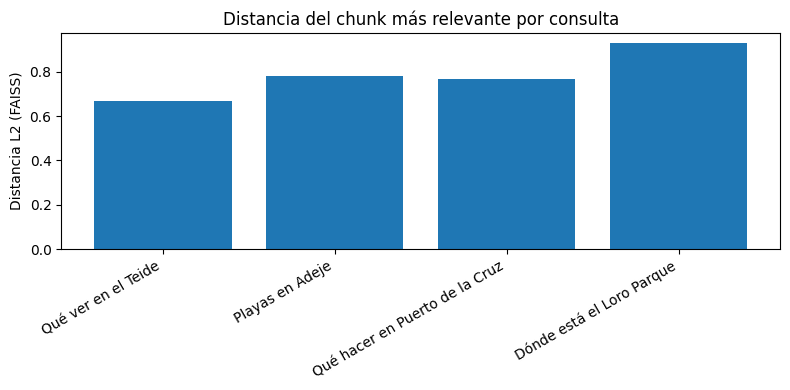

In [21]:
queries = [
    "Qué ver en el Teide",
    "Playas en Adeje",
    "Qué hacer en Puerto de la Cruz",
    "Dónde está el Loro Parque",
]

distances = []

for q in queries:
    r = retrieve(
        query=q,
        chunks=rag["chunks"],
        index=rag["index"],
        metadata=rag["metadata"],
        k=1,
    )
    distances.append(r[0]["distance"])

plt.figure(figsize=(8, 4))
plt.bar(range(len(queries)), distances)
plt.xticks(range(len(queries)), queries, rotation=30, ha="right")
plt.ylabel("Distancia L2 (FAISS)")
plt.title("Distancia del chunk más relevante por consulta")
plt.tight_layout()
plt.show()

## 17. Resetear memoria

In [20]:
assistant.reset_memory()

2026-06-12 01:25:31,861 - src.memory - INFO - Memoria conversacional reiniciada.
2026-06-12 01:25:31,862 - TenerifeAssistant - INFO - Memoria de conversación reiniciada.


## 18. Análisis crítico

### Fortalezas

- Uso de un modelo comercial (OpenAI) integrado con un pipeline RAG sobre una guía en PDF turística real.
- Recuperación semántica mediante FAISS y embeddings, con metadatos que permiten citar las páginas de la guía.
- Memoria conversacional que permite gestionar diálogos multiturno.
- Uso de function calling para complementar la información del RAG con herramientas externas.
- Arquitectura modular (código en `src/`) y separación clara entre lógica de negocio y cuaderno de experimentación.


### Limitaciones

- El chunking se basa principalmente en longitud de texto, sin tener en cuenta la estructura semántica del documento.
- No se aplica un reranking adicional sobre los resultados de FAISS.
- La evaluación del RAG es básica y no se utilizan métricas específicas de calidad de respuesta (por ejemplo, frameworks de evaluación de RAG).
- El modelo puede generar información no presente en la guía si el contexto es insuficiente o ambiguo.



## 19. Conclusión

En este cuaderno se ha documentado el funcionamiento de un asistente turístico de Tenerife basado en modelos de lenguaje de gran tamaño, combinando:

- Recuperación aumentada (RAG) sobre una guía turística en PDF.
- Diálogo multiturno con memoria conversacional.
- Llamadas a herramientas externas mediante function calling.
- Evaluación básica del componente de recuperación.
- Análisis crítico de las fortalezas, limitaciones y posibles mejoras.
- Uso de Streamlit para tener una conversacion con la AI.

El sistema resultante es modular, reproducible y extensible.